# Phase 3: Exploratory Data Analysis (EDA) & Empirical Validation
**Objective:** To load the Silver (Feature-Engineered) dataset and empirically validate that the procedural friction rules encoded during the simulation (e.g., weather delays, COD friction, spatial density) successfully manifested in the target variable (`actual_time_diff_seconds`). 

**First Step:** Data Profiling and Sanity Checks.

In [2]:
# ==========================================
# 1. MASTER SETUP & IMPORTS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress annoying warnings for a clean notebook
warnings.filterwarnings('ignore')

# Set aesthetic parameters for all charts (makes them look thesis-ready!)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 120})

# ==========================================
# 2. LOAD SILVER DATASET
# ==========================================
# Define the path to the processed Silver dataset
data_path = '../data/processed/silver_historical_deliveries.csv'

# Load the dataset
df = pd.read_csv(data_path)

print("✅ Libraries loaded successfully.")
print(f"📊 Dataset Shape: {df.shape[0]:,} Rows and {df.shape[1]} Columns")

✅ Libraries loaded successfully.
📊 Dataset Shape: 585,077 Rows and 26 Columns


In [3]:
# Define the path to the processed Silver dataset
data_path = '../data/processed/silver_historical_deliveries.csv'

# Load the dataset
df = pd.read_csv(data_path)

# Display the shape (Rows, Columns) and the first 5 rows
print(f"📊 Dataset Shape: {df.shape[0]:,} Rows and {df.shape[1]} Columns")
display(df.head())

📊 Dataset Shape: 585,077 Rows and 26 Columns


,actual_time_diff_seconds,driver_id,prev_customer_id,customer_id,destination_grid_id,origin_grid_id,vehicle_type_id,location_type,prev_location_type,is_pin_verified,...,trip_progress_id,google_eta_seconds,google_distance_meters,prev_cod_amount,rain_volume_1h,trip_sequence_num,trip_progress_ratio,trip_id,branch_id,date
0,3351.0,D_001,HUB_B_001,C_092,88611cb333fffff,HUB_B_001,MOTORCYCLE,HOME,HUB,True,...,0,513,2298,0.0,0.47,1,0.01,TRIP_20200101_B_001_D_001,B_001,2020-01-01
1,623.0,D_001,C_092,C_189,88611cb159fffff,88611cb333fffff,MOTORCYCLE,HOME,HOME,False,...,0,67,348,6850.0,0.41,2,0.03,TRIP_20200101_B_001_D_001,B_001,2020-01-01
2,498.0,D_001,C_189,C_158,88611cb159fffff,88611cb159fffff,MOTORCYCLE,APARTMENT,HOME,True,...,0,139,681,1899.0,0.43,3,0.04,TRIP_20200101_B_001_D_001,B_001,2020-01-01
3,447.0,D_001,C_158,C_123,88611cb151fffff,88611cb159fffff,MOTORCYCLE,APARTMENT,APARTMENT,True,...,1,160,928,0.0,0.36,4,0.06,TRIP_20200101_B_001_D_001,B_001,2020-01-01
4,281.0,D_001,C_123,C_188,88611cb151fffff,88611cb151fffff,MOTORCYCLE,WAREHOUSE,APARTMENT,True,...,1,61,394,0.0,0.33,5,0.07,TRIP_20200101_B_001_D_001,B_001,2020-01-01


In [4]:
# Check memory usage and data types
print("🔍 DATASET INFO & TYPES:")
print("-" * 40)
df.info()

🔍 DATASET INFO & TYPES:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585077 entries, 0 to 585076
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   actual_time_diff_seconds  585077 non-null  float64
 1   driver_id                 585077 non-null  object 
 2   prev_customer_id          585077 non-null  object 
 3   customer_id               585077 non-null  object 
 4   destination_grid_id       585077 non-null  object 
 5   origin_grid_id            585077 non-null  object 
 6   vehicle_type_id           585077 non-null  object 
 7   location_type             585077 non-null  object 
 8   prev_location_type        585077 non-null  object 
 9   is_pin_verified           585077 non-null  bool   
 10  weather_code              585077 non-null  int64  
 11  month_of_year             585077 non-null  int64  
 12  day_of_week               585077 no

In [5]:
# Check for missing values in every column
print("⚠️ MISSING VALUES CHECK:")
print("-" * 40)
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]

if missing_data.empty:
    print("✅ No missing values found! The dataset is perfectly clean.")
else:
    print("❌ Missing values detected:")
    print(missing_data)

⚠️ MISSING VALUES CHECK:
----------------------------------------
✅ No missing values found! The dataset is perfectly clean.


In [6]:
# Isolate the Dense Numerical features + the Target Variable for a quick statistical summary
numerical_cols = [
    'actual_time_diff_seconds', 'google_eta_seconds', 'google_distance_meters', 
    'prev_cod_amount', 'rain_volume_1h', 'trip_sequence_num', 'trip_progress_ratio'
]

# Display the summary statistics, rounded to 2 decimal places for readability
display(df[numerical_cols].describe().round(2))

,actual_time_diff_seconds,google_eta_seconds,google_distance_meters,prev_cod_amount,rain_volume_1h,trip_sequence_num,trip_progress_ratio
count,585077.00,585077.00,585077.00,585077.00,585077.00,585077.00,585077.00
mean,289.56,86.53,508.19,2226.85,1.18,31.89,0.51
std,292.46,114.74,605.92,3459.48,2.74,19.79,0.29
min,-266.00,0.00,5.00,0.00,0.00,1.00,0.01
25%,141.00,37.00,232.00,0.00,0.00,15.00,0.26
50%,229.00,59.00,361.00,0.00,0.00,30.00,0.51
75%,334.00,94.00,553.00,3850.00,0.66,46.00,0.76
max,7406.00,2831.00,7731.00,14999.00,19.62,126.00,1.00


## 2. Empirical Validation of Simulated Physics
Since this Bronze/Silver dataset was generated via the LamiGo simulation engines (Phase 2), the underlying causal relationships are mathematically known. For instance, the `physics_engine.py` explicitly injects delays for unverified pins, complex building access (Apartments vs. Homes), and physical cash counting. 

The purpose of this Exploratory Data Analysis is **not** discovery, but **Empirical Validation**. We must confirm that these sub-additive, deterministic rules successfully manifested in the final target variable (`actual_time_diff_seconds`) despite the injection of Gaussian noise, complex interactions, and the driver learning mechanics.

*Note: Outliers (e.g., massive delays from rare edge cases) are intentionally kept in this phase to observe the raw simulation behavior. Transformation and clipping will occur during the deep learning encoding phase.*

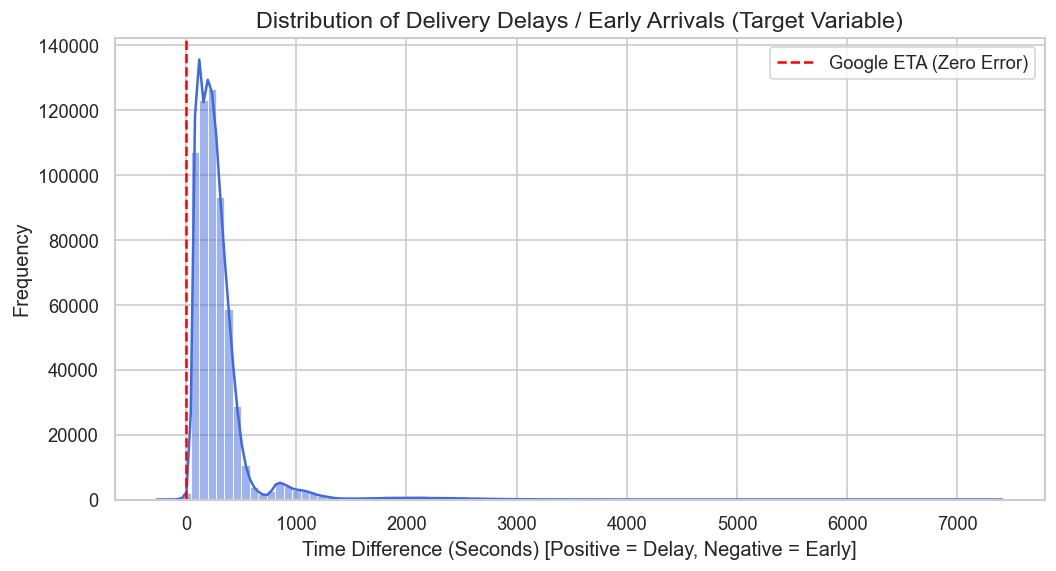

In [7]:
# 1. Distribution of the Target Variable (Time Difference)
plt.figure(figsize=(10, 5))
sns.histplot(df['actual_time_diff_seconds'], bins=100, kde=True, color='royalblue')
plt.title('Distribution of Delivery Delays / Early Arrivals (Target Variable)', fontsize=14)
plt.xlabel('Time Difference (Seconds) [Positive = Delay, Negative = Early]', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(0, color='red', linestyle='--', label='Google ETA (Zero Error)')
plt.legend()
plt.show()

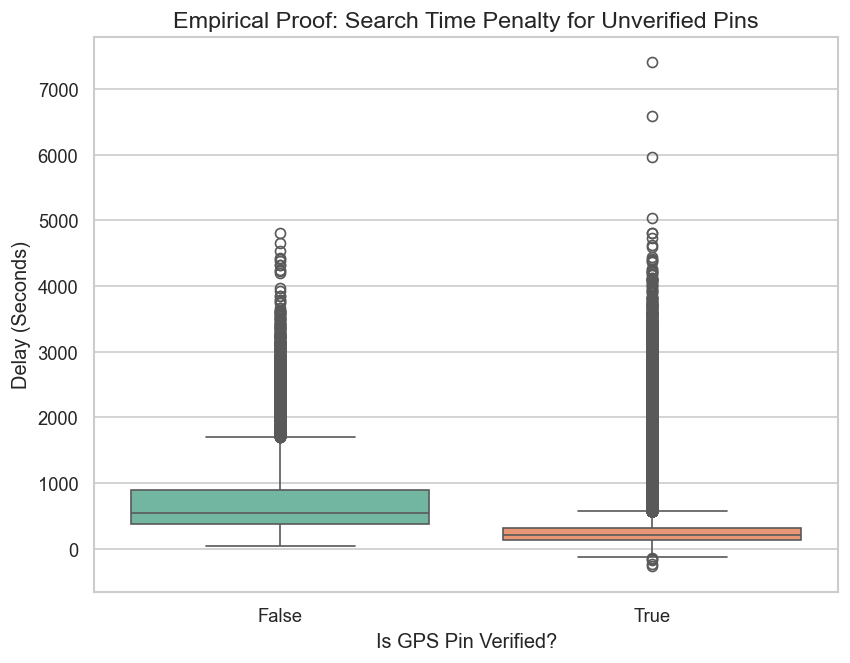

Average Delay by Pin Status:
Verified (True): 261.54 seconds
Unverified (False): 665.25 seconds
Difference: 403.71 seconds


In [8]:
# 2. Impact of Pin Verification on Delays
plt.figure(figsize=(8, 6))
# We use a boxplot to see the median and the spread of the delays
sns.boxplot(x='is_pin_verified', y='actual_time_diff_seconds', data=df, palette='Set2')
plt.title('Empirical Proof: Search Time Penalty for Unverified Pins', fontsize=14)
plt.xlabel('Is GPS Pin Verified?', fontsize=12)
plt.ylabel('Delay (Seconds)', fontsize=12)
plt.show()

# Print the mathematical proof
pin_means = df.groupby('is_pin_verified')['actual_time_diff_seconds'].mean().round(2)
print("Average Delay by Pin Status:")
print(f"Verified (True): {pin_means[True]} seconds")
print(f"Unverified (False): {pin_means[False]} seconds")
print(f"Difference: {pin_means[False] - pin_means[True]:.2f} seconds")

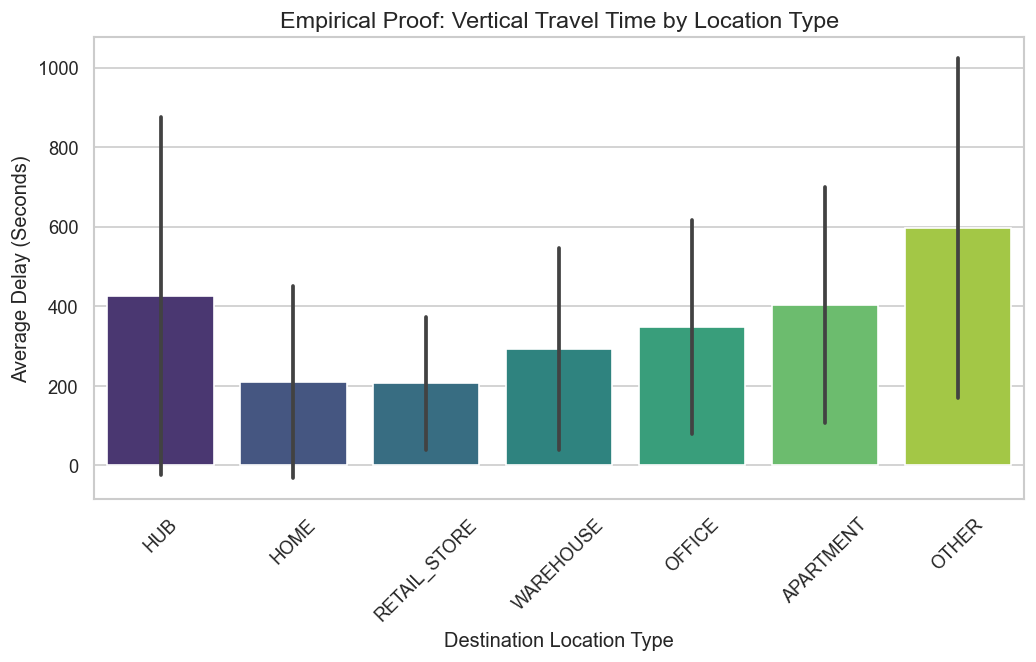

In [9]:
# 3. Impact of Building Type on Delays
plt.figure(figsize=(10, 5))
# We sort the order based on your physics engine rules to see the visual staircase
order = ['HUB', 'HOME', 'RETAIL_STORE', 'WAREHOUSE', 'OFFICE', 'APARTMENT', 'OTHER']
sns.barplot(x='location_type', y='actual_time_diff_seconds', data=df, order=order, palette='viridis', ci='sd')
plt.title('Empirical Proof: Vertical Travel Time by Location Type', fontsize=14)
plt.xlabel('Destination Location Type', fontsize=12)
plt.ylabel('Average Delay (Seconds)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

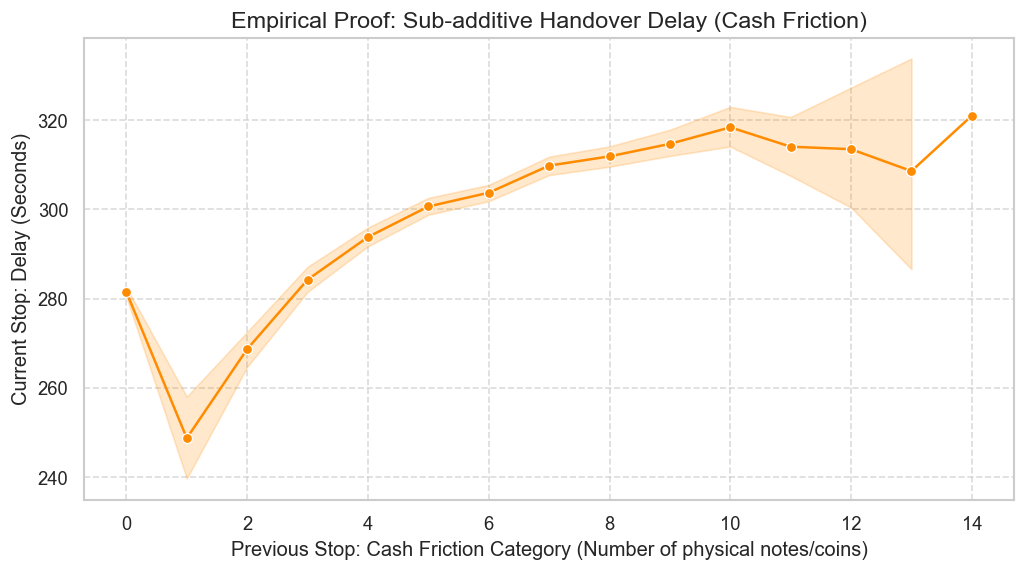

In [10]:
# 4. Impact of Physical Cash Counting on Next-Stop Delays
plt.figure(figsize=(10, 5))
sns.lineplot(x='prev_cod_friction_code', y='actual_time_diff_seconds', data=df, color='darkorange', marker='o')
plt.title('Empirical Proof: Sub-additive Handover Delay (Cash Friction)', fontsize=14)
plt.xlabel('Previous Stop: Cash Friction Category (Number of physical notes/coins)', fontsize=12)
plt.ylabel('Current Stop: Delay (Seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

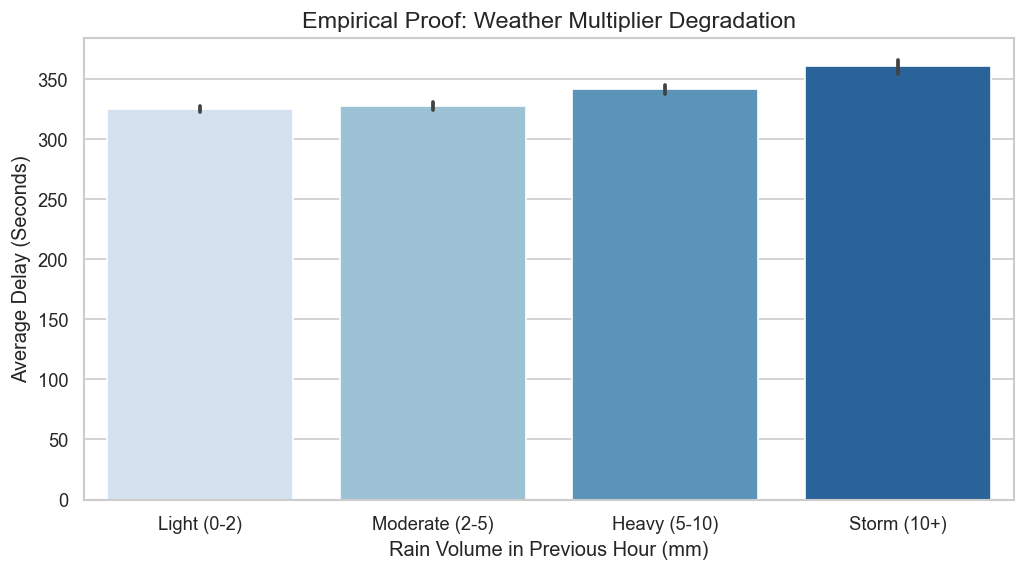

In [11]:
# 5. Impact of Rain Volume on Delays
plt.figure(figsize=(10, 5))
# Group rain into bins to make the trend clearer, ignoring 0 rain (dry days)
rain_df = df[df['rain_volume_1h'] > 0].copy()
rain_df['Rain Bin (mm)'] = pd.cut(rain_df['rain_volume_1h'], bins=[0, 2, 5, 10, 20], labels=['Light (0-2)', 'Moderate (2-5)', 'Heavy (5-10)', 'Storm (10+)'])

sns.barplot(x='Rain Bin (mm)', y='actual_time_diff_seconds', data=rain_df, palette='Blues')
plt.title('Empirical Proof: Weather Multiplier Degradation', fontsize=14)
plt.xlabel('Rain Volume in Previous Hour (mm)', fontsize=12)
plt.ylabel('Average Delay (Seconds)', fontsize=12)
plt.show()

## 3. Correlation Matrix and Human Fatigue Analysis
In this final validation step, we examine the linear relationships between our dense numerical features. 

**Note for Thesis:** While we expect positive correlations between variables like `rain_volume` or `trip_sequence_num` and the `actual_time_diff_seconds`, the relationships in LamiGo are often non-linear (sub-additive). A standard heatmap will show us the "strength" of the linear trend, but the DeepFM model will eventually be used to capture the deeper, complex interactions that a correlation matrix might miss.

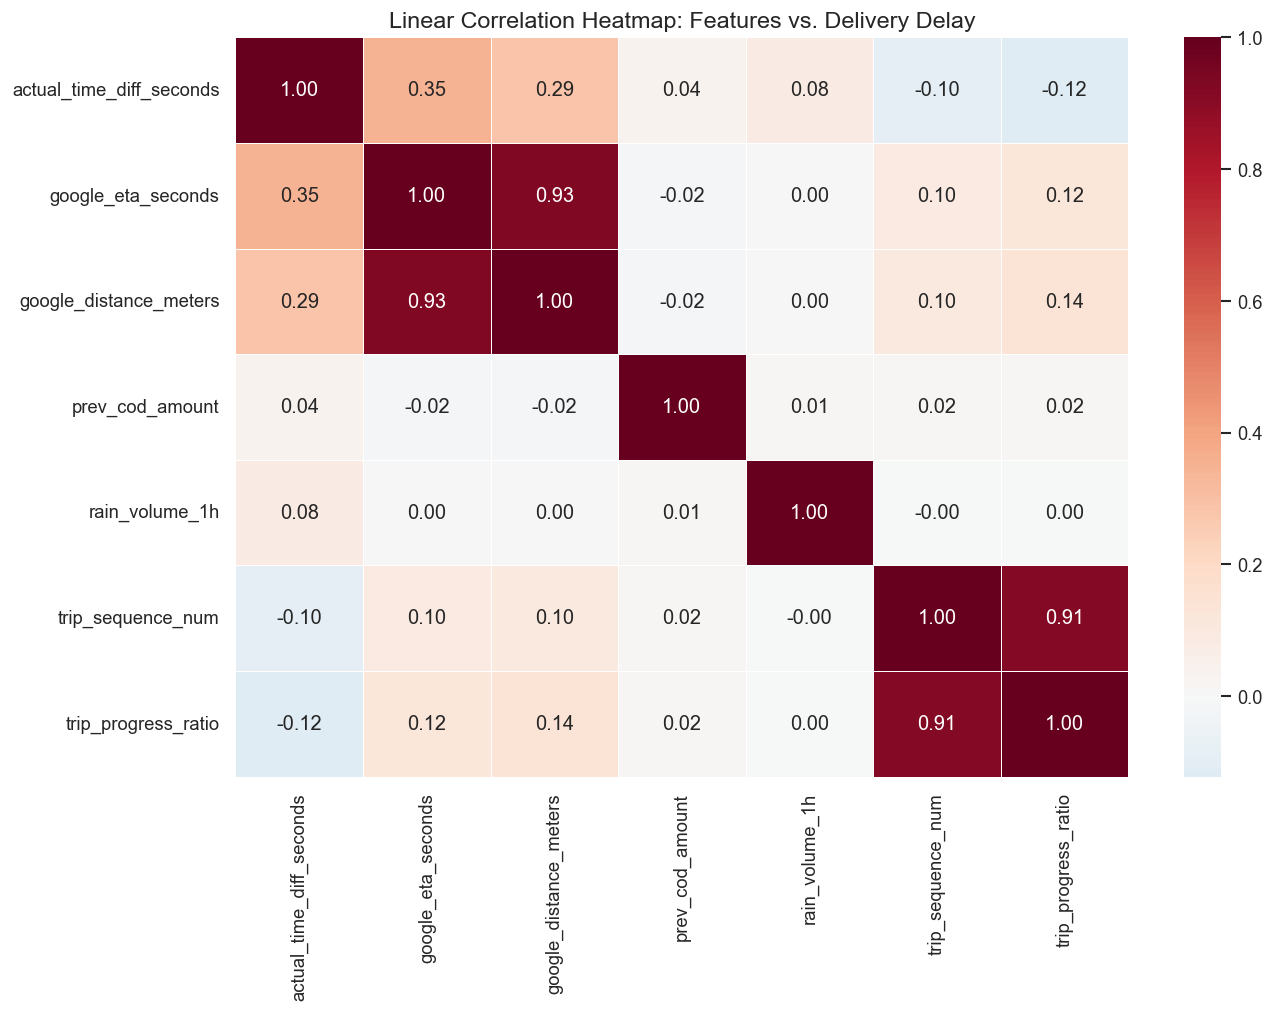

In [12]:
# 6. Numerical Correlation Heatmap
plt.figure(figsize=(12, 8))

# Select only the dense numerical features for the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=.5)
plt.title('Linear Correlation Heatmap: Features vs. Delivery Delay', fontsize=14)
plt.show()

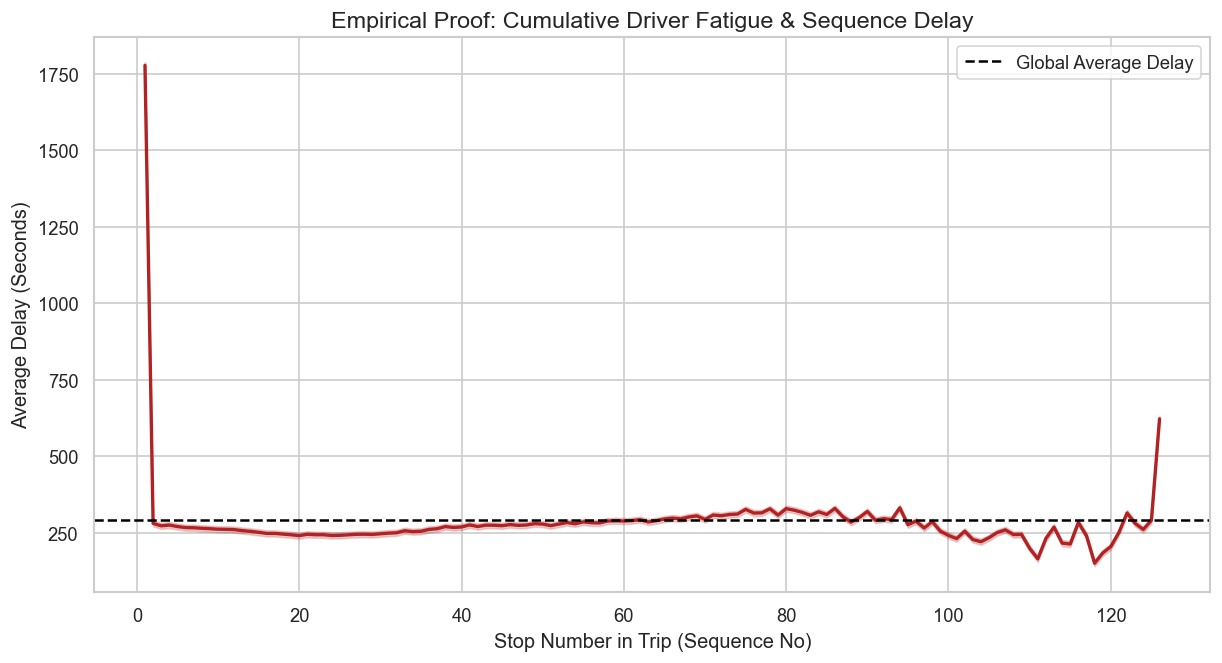

In [13]:
# 7. Impact of Trip Sequence (Fatigue) on Delay
plt.figure(figsize=(12, 6))

# We group by sequence number and calculate the mean delay
fatigue_trend = df.groupby('trip_sequence_num')['actual_time_diff_seconds'].mean()

sns.lineplot(x=fatigue_trend.index, y=fatigue_trend.values, color='firebrick', linewidth=2)
plt.fill_between(fatigue_trend.index, fatigue_trend.values - 10, fatigue_trend.values + 10, alpha=0.2, color='firebrick')

plt.title('Empirical Proof: Cumulative Driver Fatigue & Sequence Delay', fontsize=14)
plt.xlabel('Stop Number in Trip (Sequence No)', fontsize=12)
plt.ylabel('Average Delay (Seconds)', fontsize=12)
plt.axhline(df['actual_time_diff_seconds'].mean(), color='black', linestyle='--', label='Global Average Delay')
plt.legend()
plt.show()

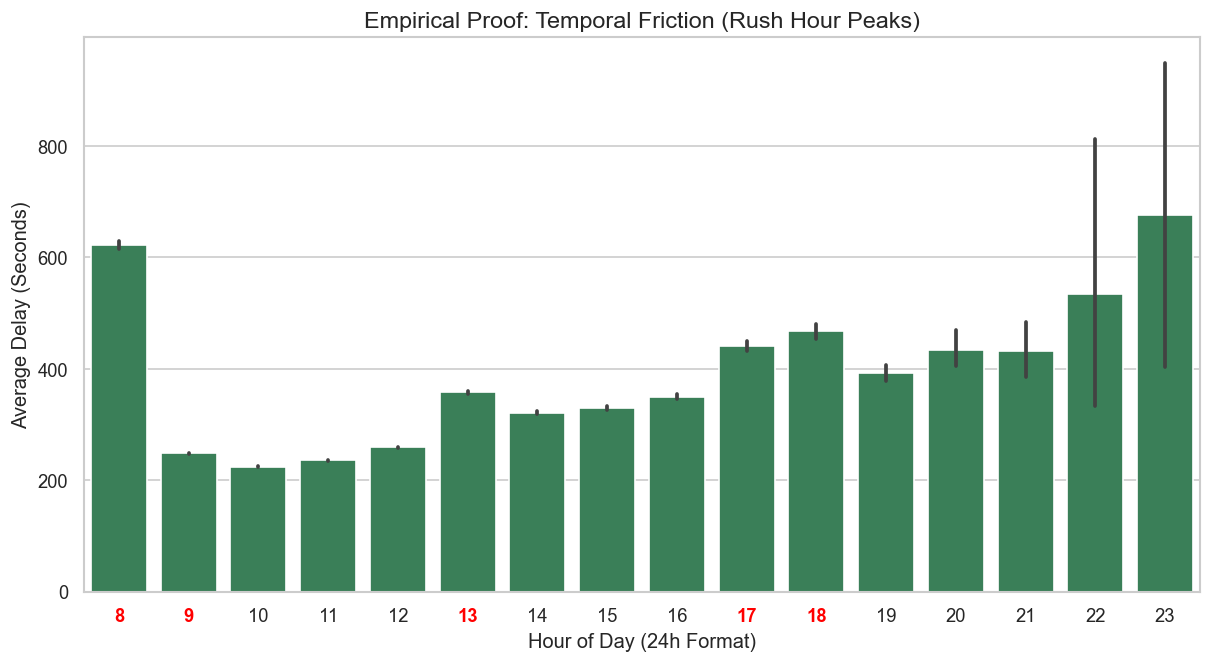

In [14]:
# 8. Impact of Time of Day on Delays (Rush Hour Validation)
plt.figure(figsize=(12, 6))

# Ensure the hours are sorted numerically on the X-axis
hour_order = sorted(df['hour_of_day'].unique())

sns.barplot(x='hour_of_day', y='actual_time_diff_seconds', data=df, order=hour_order, color='seagreen')
plt.title('Empirical Proof: Temporal Friction (Rush Hour Peaks)', fontsize=14)
plt.xlabel('Hour of Day (24h Format)', fontsize=12)
plt.ylabel('Average Delay (Seconds)', fontsize=12)

# Define the hours we want to highlight
rush_hours = ['8', '9', '13', '17', '18']

# Robust highlighting: Loop through labels and check the text content
ax = plt.gca()
for label in ax.get_xticklabels():
    if label.get_text() in rush_hours:
        label.set_color('red')
        label.set_weight('bold')
        label.set_fontsize(11)

plt.show()

## 5. Outlier Analysis: Trip Workload Distribution
In this section, we analyze the distribution of deliveries (stops) per trip. Since the simulation clusters orders based on demand and vehicle capacity, we want to ensure that the "Workload Intensity" remains within realistic bounds for a standard delivery shift in Sri Lanka.

We will also check the Target Variable (`actual_time_diff_seconds`) for extreme statistical outliers that might require clipping during the model training phase.

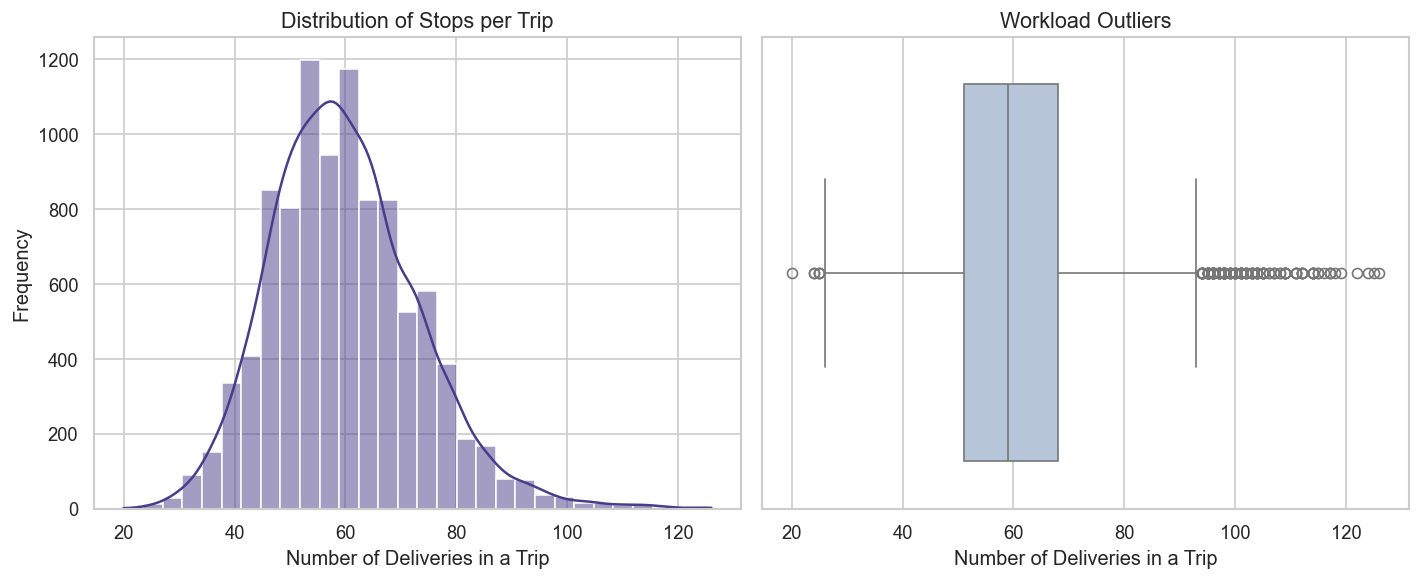

📊 WORKLOAD STATISTICS:
Min Deliveries: 20
Max Deliveries: 126
Mean Deliveries: 59.87
Median Deliveries: 59.0


In [15]:
# 9. Distribution of Deliveries per Trip
# Calculate the number of stops for each unique trip
stops_per_trip = df.groupby('trip_id').size()

plt.figure(figsize=(12, 5))

# Plot 1: Histogram
plt.subplot(1, 2, 1)
sns.histplot(stops_per_trip, bins=30, kde=True, color='darkslateblue')
plt.title('Distribution of Stops per Trip', fontsize=13)
plt.xlabel('Number of Deliveries in a Trip')
plt.ylabel('Frequency')

# Plot 2: Boxplot (To highlight the outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=stops_per_trip, color='lightsteelblue')
plt.title('Workload Outliers', fontsize=13)
plt.xlabel('Number of Deliveries in a Trip')

plt.tight_layout()
plt.show()

# Print Outlier Statistics
print("📊 WORKLOAD STATISTICS:")
print(f"Min Deliveries: {stops_per_trip.min()}")
print(f"Max Deliveries: {stops_per_trip.max()}")
print(f"Mean Deliveries: {stops_per_trip.mean():.2f}")
print(f"Median Deliveries: {stops_per_trip.median()}")

In [16]:
# ==========================================
# 11. REMOVING HIGH-SIDE WORKLOAD OUTLIERS ONLY
# ==========================================

# Step 1: Calculate the Upper Bound based on the IQR
stops_per_trip = df.groupby('trip_id').size()
Q1 = stops_per_trip.quantile(0.25)
Q3 = stops_per_trip.quantile(0.75)
IQR = Q3 - Q1

# We only define the upper bound to filter out "Impossible" high-volume trips
upper_bound = Q3 + 1.5 * IQR

# Step 2: Identify only the Trip IDs that exceed the upper bound
outlier_trips = stops_per_trip[stops_per_trip > upper_bound].index
# We keep everything else (including low-count trips)
valid_trips = stops_per_trip[stops_per_trip <= upper_bound].index

# Step 3: Create the cleaned dataframe
df_before_count = len(df)
df_cleaned = df[df['trip_id'].isin(valid_trips)].copy()
df_after_count = len(df_cleaned)

# Step 4: Report the counts
trips_removed = len(outlier_trips)
rows_removed = df_before_count - df_after_count

print("✂️ HIGH-SIDE OUTLIER REMOVAL SUMMARY:")
print("-" * 40)
print(f"Upper Filtering Bound: {upper_bound:.2f} stops per trip")
print(f"Impossible High-Volume Trips Removed: {trips_removed:,}")
print(f"Total Delivery Rows Removed: {rows_removed:,}")
print(f"Remaining Rows in Dataset: {df_after_count:,}")
print(f"Percentage of Data Retained: {(df_after_count/df_before_count)*100:.2f}%")

# Update our main df variable for the next steps
df = df_cleaned

✂️ HIGH-SIDE OUTLIER REMOVAL SUMMARY:
----------------------------------------
Upper Filtering Bound: 93.50 stops per trip
Impossible High-Volume Trips Removed: 143
Total Delivery Rows Removed: 14,637
Remaining Rows in Dataset: 570,440
Percentage of Data Retained: 97.50%


In [17]:
# 10. Analyzing Extreme Delay Outliers (The Target Variable)
# Calculate Interquartile Range (IQR) for the Target
Q1 = df['actual_time_diff_seconds'].quantile(0.25)
Q3 = df['actual_time_diff_seconds'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['actual_time_diff_seconds'] < lower_bound) | (df['actual_time_diff_seconds'] > upper_bound)]

print("🕒 TARGET VARIABLE OUTLIERS:")
print(f"Lower Bound (Seconds): {lower_bound:.2f}")
print(f"Upper Bound (Seconds): {upper_bound:.2f}")
print(f"Number of Outlier Rows: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

# Let's look at the Top 5 most "delayed" deliveries
display(df.sort_values('actual_time_diff_seconds', ascending=False).head(5))

🕒 TARGET VARIABLE OUTLIERS:
Lower Bound (Seconds): -150.00
Upper Bound (Seconds): 626.00
Number of Outlier Rows: 30,845 (5.41%)


,actual_time_diff_seconds,driver_id,prev_customer_id,customer_id,destination_grid_id,origin_grid_id,vehicle_type_id,location_type,prev_location_type,is_pin_verified,...,trip_progress_id,google_eta_seconds,google_distance_meters,prev_cod_amount,rain_volume_1h,trip_sequence_num,trip_progress_ratio,trip_id,branch_id,date
584202,7406.0,D_010,C_145,HUB_B_001,88611cb335fffff,88611cb11bfffff,LORRY,HUB,HOME,True,...,20,2818,7201,3899.0,14.35,48,1.00,TRIP_20240206_B_001_D_010,B_001,2024-02-06
100632,6594.0,D_010,C_297,HUB_B_001,88611cb335fffff,88611cb025fffff,LORRY,HUB,HOME,True,...,20,2498,6480,0.0,12.15,49,1.00,TRIP_20200915_B_001_D_010,B_001,2020-09-15
401269,5969.0,D_010,HUB_B_001,C_322,88611cb155fffff,HUB_B_001,LORRY,HOME,HUB,True,...,0,1927,4136,0.0,1.55,1,0.01,TRIP_20221025_B_001_D_010,B_001,2022-10-25
337974,5043.0,D_010,HUB_B_001,C_054,88611cb155fffff,HUB_B_001,LORRY,APARTMENT,HUB,True,...,0,1153,3011,0.0,7.71,1,0.01,TRIP_20220516_B_001_D_010,B_001,2022-05-16
247503,4815.0,D_001,HUB_B_001,C_191,88611cb10bfffff,HUB_B_001,MOTORCYCLE,HOME,HUB,True,...,0,963,4273,0.0,5.70,1,0.04,TRIP_20210927_B_001_D_001,B_001,2021-09-27


## 6. Data Engineering: Transformation & Persistence Registry
With the empirical validation complete and outliers removed, the dataset is now prepared for the **DeepFM (Deep Factorization Machine)** architecture. 

To ensure the neural network converges efficiently and can be used for future inference, we must apply two distinct transformation strategies:

1. **Categorical Embedding (Label Encoding):** Sparse features (IDs, Locations, Grid Bins) are mapped to unique integers. These will serve as indices for the **Embedding Layer**, allowing the model to learn high-dimensional latent relationships between specific drivers and neighborhoods.
2. **Feature Scaling (Standardization):** Dense numerical features are transformed to a mean of $\mu=0$ and standard deviation of $\sigma=1$. This prevents features with large magnitudes (e.g., `google_distance_meters`) from dominating the gradient updates over smaller features (e.g., `trip_progress_ratio`).

**Persistence Strategy:** To prevent **Inference Mismatch**, all transformation parameters (mappings and scalers) are serialized into `joblib` objects within the `models/metadata/` directory. This creates a "Transformation Registry" that allows the model to be deployed or tested on new, unseen data using the exact same scaling parameters used during training.

In [18]:
import joblib # The industry standard for saving ML objects
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# ==========================================
# 13. DEFINE FEATURE GROUPS (Table 3.2.2 & 3.2.3)
# ==========================================

# Sparse (Categorical) - These will go into the Embedding Layer of DeepFM
sparse_features = [
    'driver_id', 'prev_customer_id', 'customer_id', 'destination_grid_id', 
    'origin_grid_id', 'vehicle_type_id', 'location_type', 'prev_location_type', 
    'is_pin_verified', 'weather_code', 'month_of_year', 'day_of_week', 
    'hour_of_day', 'prev_cod_friction_code', 'trip_sequence_id', 'trip_progress_id'
]

# Dense (Numerical) - These will go into the Continuous Layer of DeepFM
dense_features = [
    'google_eta_seconds', 'google_distance_meters', 'prev_cod_amount', 
    'rain_volume_1h', 'trip_sequence_num', 'trip_progress_ratio'
]

target = ['actual_time_diff_seconds']

# ==========================================
# 14. APPLY & TRACK TRANSFORMATIONS (FIXED SORTING)
# ==========================================
import os
os.makedirs('../models/metadata', exist_ok=True)

print("🧪 Starting Feature Transformation Registry...")

# A. Transform Sparse Features (Label Encoding)
label_encoders = {}
for col in sparse_features:
    le = LabelEncoder()
    
    # FIX: Only convert true string columns to strings. 
    # Leave numeric categorical features as integers so they sort correctly!
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = df[col].astype(str)
    else:
        df[col] = df[col].astype(int) # Keeps 2 before 10
        
    df[col] = le.fit_transform(df[col])
    
    # SAVE THE ENCODER
    joblib.dump(le, f'../models/metadata/le_{col}.joblib')
    label_encoders[col] = le
    print(f"✅ Encoded {col} ({len(le.classes_)} unique categories)")

# B. Transform Dense Features (Standard Scaling)
scaler = StandardScaler()
df[dense_features] = scaler.fit_transform(df[dense_features])

# SAVE THE SCALER
joblib.dump(scaler, '../models/metadata/dense_scaler.joblib')
print(f"✅ Scaled {len(dense_features)} numerical features to Mean=0, Std=1")

# C. Quick Check
print("-" * 40)
print(f"💎 Transformation Complete. Data is now 'DeepFM Ready'.")
display(df[['trip_sequence_num', 'trip_sequence_id', 'hour_of_day']].head(5))

🧪 Starting Feature Transformation Registry...
✅ Encoded driver_id (20 unique categories)
✅ Encoded prev_customer_id (642 unique categories)
✅ Encoded customer_id (642 unique categories)
✅ Encoded destination_grid_id (86 unique categories)
✅ Encoded origin_grid_id (88 unique categories)
✅ Encoded vehicle_type_id (2 unique categories)
✅ Encoded location_type (7 unique categories)
✅ Encoded prev_location_type (7 unique categories)
✅ Encoded is_pin_verified (2 unique categories)
✅ Encoded weather_code (9 unique categories)
✅ Encoded month_of_year (12 unique categories)
✅ Encoded day_of_week (7 unique categories)
✅ Encoded hour_of_day (16 unique categories)
✅ Encoded prev_cod_friction_code (15 unique categories)
✅ Encoded trip_sequence_id (93 unique categories)
✅ Encoded trip_progress_id (21 unique categories)
✅ Scaled 6 numerical features to Mean=0, Std=1
----------------------------------------
💎 Transformation Complete. Data is now 'DeepFM Ready'.


,trip_sequence_num,trip_sequence_id,hour_of_day
0,-1.584213,0,0
1,-1.532065,1,1
2,-1.479916,2,1
3,-1.427768,3,1
4,-1.375620,4,1


In [19]:
# ==========================================
# 15. EXPORT GOLD DATASET FOR DEEPFM
# ==========================================

# Define the final output path
gold_data_path = '../data/processed/gold_historical_deliveries.csv'

# Save the fully transformed and outlier-filtered dataframe
# We keep the index=False to prevent an extra "unnamed" column
df.to_csv(gold_data_path, index=False)

print("🏆 GOLD DATASET GENERATED!")
print("-" * 40)
print(f"📍 Location: {gold_data_path}")
print(f"📊 Final Row Count: {len(df):,}")
print(f"🛠️ Encoders/Scalers Saved to: models/metadata/")
print("-" * 40)
print("🚀 Ready for Phase 4: DeepFM Model Training.")

🏆 GOLD DATASET GENERATED!
----------------------------------------
📍 Location: ../data/processed/gold_historical_deliveries.csv
📊 Final Row Count: 570,440
🛠️ Encoders/Scalers Saved to: models/metadata/
----------------------------------------
🚀 Ready for Phase 4: DeepFM Model Training.
